# Bridge Week 1: Exploratory Preprocessing and ShakeMap Coverage Check

This notebook captures the earlier exploratory preprocessing work used to understand the bridge inventory and its spatial overlap with the Northridge ShakeMap raster.

## What this notebook does
- loads the raw California bridge inventory from `data/CA25.txt`
- inspects the packed coordinate format in the source file
- converts coordinates into decimal degrees
- checks which bridges fall inside the ShakeMap footprint
- writes an affected-bridge subset to `data/processed/bridges_with_pga_affected_only.csv`

## When to use it
Use this notebook if you want to understand the original preprocessing logic step by step. For the cleaner main workflow, start with `PGA_bridge.ipynb`.


In [1]:
from runtime_checks import ensure_packages, ensure_supported_runtime

ensure_supported_runtime()
ensure_packages([
    "numpy",
    "pandas",
    "matplotlib",
    "scipy",
    "sklearn",
    "rasterio",
    "geopandas",
    "shapely",
    "seaborn",
    "rasterstats",
])

print("Environment check passed. Use a local Python kernel from the project environment.")


Environment check passed. Use a local Python kernel from the project environment.


In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
import rasterio
import matplotlib.pyplot as plt

from project_paths import build_paths, require_paths

PATHS = build_paths()
NBI_FILE = PATHS["NBI_FILE"]
PGA_FLT = PATHS["PGA_RASTER"]
PGA_HDR = PATHS["PGA_RASTER_HDR"]
AFFECTED_OUTPUT = PATHS["AFFECTED_BRIDGES_CSV"]

require_paths(PATHS, ["NBI_FILE", "PGA_RASTER", "PGA_RASTER_HDR"])

print("Project root:", PATHS["PROJECT_ROOT"])
print("NBI_FILE:", NBI_FILE)
print("PGA_FLT :", PGA_FLT)
print("Affected output:", AFFECTED_OUTPUT)


Project root: /Users/nchatterjee/Documents/Playground/Cat-411-Project-Northridge-Bridge
NBI_FILE: /Users/nchatterjee/Documents/Playground/Cat-411-Project-Northridge-Bridge/data/CA25.txt
PGA_FLT : /Users/nchatterjee/Documents/Playground/Cat-411-Project-Northridge-Bridge/data/pga_mean.flt
Affected output: /Users/nchatterjee/Documents/Playground/Cat-411-Project-Northridge-Bridge/data/processed/bridges_with_pga_affected_only.csv


In [3]:
df = pd.read_csv(NBI_FILE, low_memory=False)
print("Loaded rows:", len(df))
print("Columns:", len(df.columns))
print(df.columns[:25])

Loaded rows: 25975
Columns: 123
Index(['STATE_CODE_001', 'STRUCTURE_NUMBER_008', 'RECORD_TYPE_005A',
       'ROUTE_PREFIX_005B', 'SERVICE_LEVEL_005C', 'ROUTE_NUMBER_005D',
       'DIRECTION_005E', 'HIGHWAY_DISTRICT_002', 'COUNTY_CODE_003',
       'PLACE_CODE_004', 'FEATURES_DESC_006A', 'CRITICAL_FACILITY_006B',
       'FACILITY_CARRIED_007', 'LOCATION_009', 'MIN_VERT_CLR_010',
       'KILOPOINT_011', 'BASE_HWY_NETWORK_012', 'LRS_INV_ROUTE_013A',
       'SUBROUTE_NO_013B', 'LAT_016', 'LONG_017', 'DETOUR_KILOS_019',
       'TOLL_020', 'MAINTENANCE_021', 'OWNER_022'],
      dtype='object')


In [4]:
import numpy as np
import pandas as pd

LAT_COL = "LAT_016"
LON_COL = "LONG_017"
ID_COL  = "STRUCTURE_NUMBER_008"

def _clean_to_intlike(x):
    """Convert to float/int if possible; else NaN."""
    if pd.isna(x):
        return np.nan
    s = str(x).strip().replace(",", "")
    if s == "" or s.upper() in {"N", "NA", "NONE"}:
        return np.nan
    # remove directional letters if present
    for ch in ["N", "S", "E", "W"]:
        s = s.replace(ch, "")
    s = s.strip()
    try:
        return float(s)
    except:
        return np.nan

def nbi_packed_dms_to_decimal(v):
    """
    Handles NBI packed DMS formats like:
      LAT:  40454199  -> 40°45'41.99"
      LON:  122190700 -> 122°19'07.00"
    Also passes through values that already look like decimal degrees (abs <= 180).
    """
    if pd.isna(v):
        return np.nan

    v = float(v)

    # If it already looks like decimal degrees, keep it
    if abs(v) <= 180:
        return v

    # Convert to integer string (no decimal point)
    sign = -1 if v < 0 else 1
    s = str(int(round(abs(v))))

    # Latitude is typically 8 digits, longitude 9 digits, but we’ll handle general case:
    # last 6 digits are always MMSSss (minutes, seconds, hundredths)
    if len(s) < 7:
        return np.nan  # too short to be valid packed DMS

    deg_str = s[:-6]
    rest = s[-6:]  # MMSSss

    try:
        deg = int(deg_str)
        minutes = int(rest[:2])
        sec_whole = int(rest[2:4])
        sec_hundredths = int(rest[4:6])
    except:
        return np.nan

    seconds = sec_whole + sec_hundredths / 100.0

    # sanity
    if not (0 <= minutes < 60 and 0 <= seconds < 60):
        return np.nan

    dec = deg + minutes / 60.0 + seconds / 3600.0
    return sign * dec

# Clean raw
lat_raw = df[LAT_COL].apply(_clean_to_intlike)
lon_raw = df[LON_COL].apply(_clean_to_intlike)

# Convert
df["latitude"]  = lat_raw.apply(nbi_packed_dms_to_decimal)
df["longitude"] = lon_raw.apply(nbi_packed_dms_to_decimal)

# California longitudes should be negative
df["longitude"] = -df["longitude"].abs()

# Drop missing + keep plausible bounds
before = len(df)
df = df.dropna(subset=["latitude", "longitude"]).copy()
df = df[df["latitude"].between(20, 60) & df["longitude"].between(-140, -60)].copy()

df["structure_no"] = df[ID_COL].astype(str).str.strip()

print(f"After coord conversion: {len(df):,} (dropped {before - len(df):,})")
print("Converted LAT sample:", df["latitude"].head(10).tolist())
print("Converted LON sample:", df["longitude"].head(10).tolist())
print(df[["latitude","longitude"]].describe())


After coord conversion: 25,974 (dropped 1)
Converted LAT sample: [40.76166388888889, 34.10225, 32.72665, 34.11646944444445, 34.11296111111111, 32.68761666666666, 32.67446666666667, 34.10238888888889, 38.51086111111111, 32.67833888888889]
Converted LON sample: [-122.31861111111111, -119.10413333333332, -117.14681666666668, -119.09663055555555, -119.09228888888889, -117.12868055555555, -117.11555, -119.10411111111111, -121.39905555555556, -117.11153888888889]
           latitude     longitude
count  25974.000000  25974.000000
mean      36.450574   -119.928452
std        2.446838      2.188869
min       32.544086   -124.400364
25%       34.080859   -121.904252
50%       36.751874   -120.198331
75%       38.357971   -118.055293
max       42.002172   -114.139575


In [5]:
import numpy as np
import pandas as pd

df_raw = pd.read_csv(NBI_FILE, low_memory=False)
print("df_raw rows:", len(df_raw))
print("LAT sample:", df_raw["LAT_016"].head(10).tolist())
print("LON sample:", df_raw["LONG_017"].head(10).tolist())


df_raw rows: 25975
LAT sample: [40454199, 34060810, 32433594, 34065929, 34064666, 32411542, 32402808, 34060860, 38303910, 32404202]
LON sample: [122190700, 119061488, 117084854, 119054787, 119053224, 117074325, 117065598, 119061480, 121235660, 117064154]


In [6]:
import numpy as np
import pandas as pd

LAT_COL = "LAT_016"
LON_COL = "LONG_017"
ID_COL  = "STRUCTURE_NUMBER_008"

def nbi_packed_dms_to_decimal(v):
    # v like 40454199 -> 40°45'41.99"
    if pd.isna(v):
        return np.nan
    v = float(v)

    # if already decimal degrees (rare here), keep
    if abs(v) <= 180:
        return v

    s = str(int(abs(v)))  # remove sign and decimals
    if len(s) < 7:
        return np.nan

    deg = int(s[:-6])
    mmsscc = s[-6:]  # MM SS cc
    minutes = int(mmsscc[0:2])
    sec_whole = int(mmsscc[2:4])
    sec_cent = int(mmsscc[4:6])
    seconds = sec_whole + sec_cent/100.0

    if not (0 <= minutes < 60 and 0 <= seconds < 60):
        return np.nan

    return deg + minutes/60.0 + seconds/3600.0

# START CLEAN from df_raw (DO NOT use any old df)
df = df_raw.copy()

df["latitude"]  = df[LAT_COL].apply(nbi_packed_dms_to_decimal)
df["longitude"] = df[LON_COL].apply(nbi_packed_dms_to_decimal)

# CA longitude negative
df["longitude"] = -df["longitude"].abs()

# Keep plausible bounds
before = len(df)
df = df.dropna(subset=["latitude","longitude"]).copy()
df = df[df["latitude"].between(20, 60) & df["longitude"].between(-140, -60)].copy()

df["structure_no"] = df[ID_COL].astype(str).str.strip()

print("Before:", before)
print("After :", len(df))
print(df[["latitude","longitude"]].head(10))
print(df[["latitude","longitude"]].describe())


Before: 25975
After : 25974
    latitude   longitude
0  40.761664 -122.318611
1  34.102250 -119.104133
2  32.726650 -117.146817
3  34.116469 -119.096631
4  34.112961 -119.092289
5  32.687617 -117.128681
6  32.674467 -117.115550
7  34.102389 -119.104111
8  38.510861 -121.399056
9  32.678339 -117.111539
           latitude     longitude
count  25974.000000  25974.000000
mean      36.450574   -119.928452
std        2.446838      2.188869
min       32.544086   -124.400364
25%       34.080859   -121.904252
50%       36.751874   -120.198331
75%       38.357971   -118.055293
max       42.002172   -114.139575


In [7]:
import geopandas as gpd
from shapely.geometry import Point

gdf = gpd.GeoDataFrame(
    df[["structure_no", "latitude", "longitude"]].copy(),
    geometry=[Point(xy) for xy in zip(df["longitude"], df["latitude"])],
    crs="EPSG:4326"
)

print("gdf rows:", len(gdf))
gdf.head()

gdf rows: 25974


,structure_no,latitude,longitude,geometry
0,06 0021,40.761664,-122.318611,POINT (-122.31861 40.76166)
1,1CA0070,34.102250,-119.104133,POINT (-119.10413 34.10225)
2,1CA0095,32.726650,-117.146817,POINT (-117.14682 32.72665)
3,1CA0141,34.116469,-119.096631,POINT (-119.09663 34.11647)
4,1CA0142,34.112961,-119.092289,POINT (-119.09229 34.11296)


In [8]:
import rasterio
import numpy as np
from rasterio.transform import rowcol

with rasterio.open(PGA_FLT) as src:
    pga_raw = src.read(1, masked=True)
    transform = src.transform
    bounds = src.bounds
    r_crs = src.crs
    nodata = src.nodata

print("Raster CRS:", r_crs)
print("Raster bounds:", bounds)
print("Raw min/max:", float(pga_raw.min()), float(pga_raw.max()), "nodata:", nodata)

# The USGS ShakeMap raster stores ln(PGA), so convert back with exp().
pga_grid = np.exp(pga_raw).astype("float64")

gdf["inside_shakemap"] = (
    (gdf["longitude"] >= bounds.left) &
    (gdf["longitude"] <= bounds.right) &
    (gdf["latitude"] >= bounds.bottom) &
    (gdf["latitude"] <= bounds.top)
)

def sample_pga(lon, lat):
    if (lon < bounds.left) or (lon > bounds.right) or (lat < bounds.bottom) or (lat > bounds.top):
        return np.nan
    r, c = rowcol(transform, lon, lat)
    if r < 0 or r >= pga_grid.shape[0] or c < 0 or c >= pga_grid.shape[1]:
        return np.nan
    v = pga_grid[r, c]
    try:
        if np.ma.is_masked(v):
            return np.nan
    except Exception:
        pass
    return float(v)

gdf["pga"] = [sample_pga(lon, lat) for lon, lat in zip(gdf["longitude"], gdf["latitude"])]
gdf["pga"] = gdf["pga"].replace([np.inf, -np.inf], np.nan)

gdf_affected = gdf[gdf["inside_shakemap"] & gdf["pga"].notna()].copy()
gdf_affected.to_csv(AFFECTED_OUTPUT, index=False)

print("Total bridges:", len(gdf))
print("Inside ShakeMap:", int(gdf["inside_shakemap"].sum()))
print("With PGA:", int(gdf["pga"].notna().sum()))
print("Affected (inside+PGA):", len(gdf_affected))
print("Saved:", AFFECTED_OUTPUT)

gdf_affected[["structure_no", "latitude", "longitude", "pga"]].head(10)


Raster CRS: None
Raster bounds: BoundingBox(left=-122.625, bottom=30.69166666666667, right=-114.10833333333333, top=37.725)
Raw min/max: -7.8298869132995605 -0.14110606908798218 nodata: 999.0


Total bridges: 25974
Inside ShakeMap: 16795
With PGA: 16795
Affected (inside+PGA): 16795
Saved: /Users/nchatterjee/Documents/Playground/Cat-411-Project-Northridge-Bridge/data/processed/bridges_with_pga_affected_only.csv


,structure_no,latitude,longitude,pga
1,1CA0070,34.102250,-119.104133,0.177764
2,1CA0095,32.726650,-117.146817,0.028422
3,1CA0141,34.116469,-119.096631,0.183217
4,1CA0142,34.112961,-119.092289,0.183217
5,1CA0482,32.687617,-117.128681,0.026333
6,1CA0484,32.674467,-117.115550,0.025529
7,1CA070A,34.102389,-119.104111,0.177764
9,1CA3102,32.678339,-117.111539,0.026418
10,1CA3103,32.681767,-117.112747,0.026418
11,1CA5135,34.153631,-119.211272,0.124983


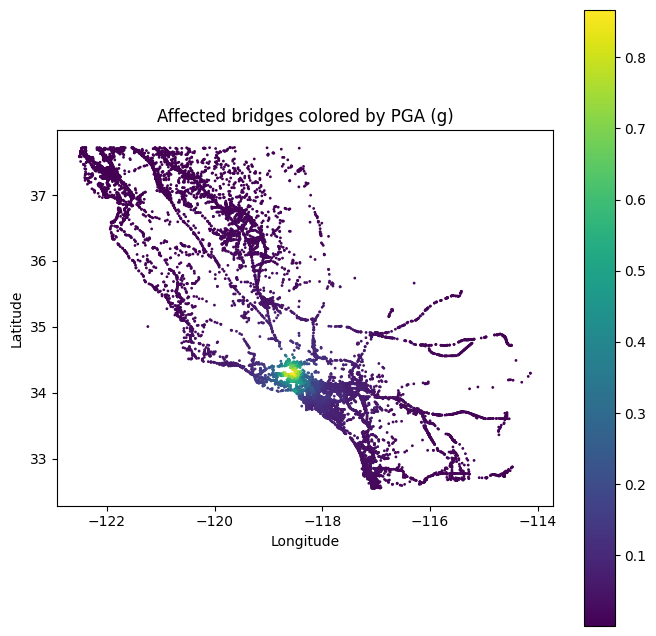

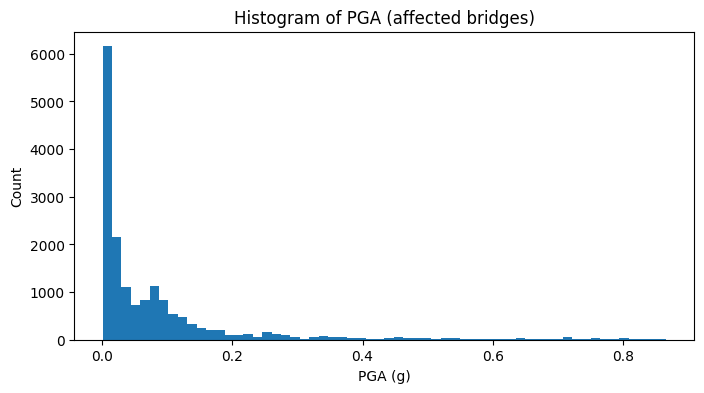

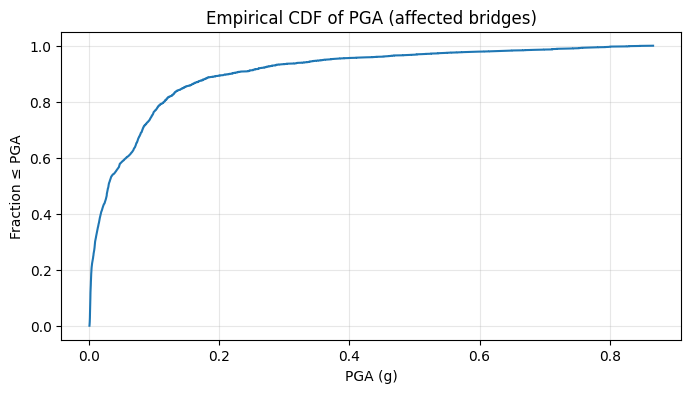

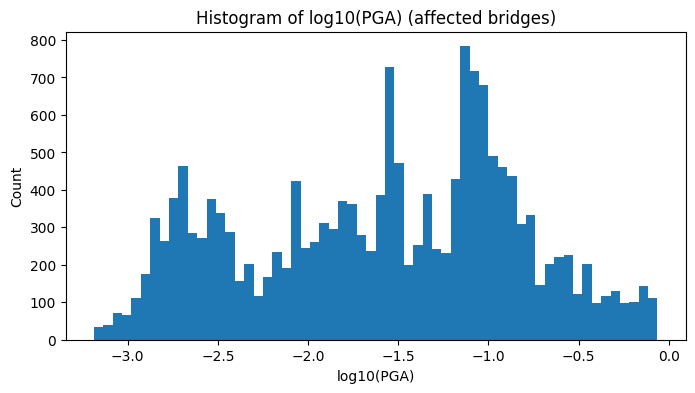

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# 1) Exposure map
ax = gdf_affected.plot(column="pga", legend=True, markersize=1, figsize=(8,8), aspect="auto")
ax.set_title("Affected bridges colored by PGA (g)")
ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
plt.show()

# 2) Histogram PGA
plt.figure(figsize=(8,4))
plt.hist(gdf_affected["pga"].values, bins=60)
plt.title("Histogram of PGA (affected bridges)")
plt.xlabel("PGA (g)"); plt.ylabel("Count")
plt.show()

# 3) CDF PGA
vals = np.sort(gdf_affected["pga"].values)
cdf = np.arange(1, len(vals)+1)/len(vals)
plt.figure(figsize=(8,4))
plt.plot(vals, cdf)
plt.title("Empirical CDF of PGA (affected bridges)")
plt.xlabel("PGA (g)"); plt.ylabel("Fraction ≤ PGA")
plt.grid(True, alpha=0.3)
plt.show()

# 4) Log-PGA histogram (often more readable)
vals_pos = gdf_affected["pga"].values
vals_pos = vals_pos[vals_pos > 0]
plt.figure(figsize=(8,4))
plt.hist(np.log10(vals_pos), bins=60)
plt.title("Histogram of log10(PGA) (affected bridges)")
plt.xlabel("log10(PGA)"); plt.ylabel("Count")
plt.show()


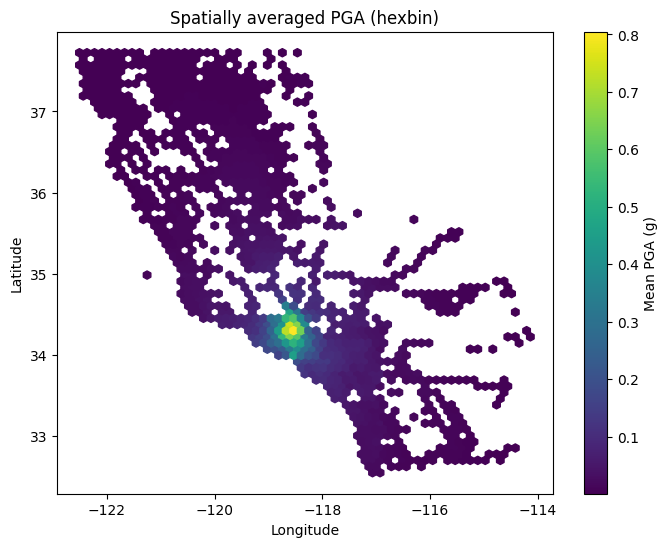

In [10]:
plt.figure(figsize=(8,6))
plt.hexbin(
    gdf_affected["longitude"],
    gdf_affected["latitude"],
    C=gdf_affected["pga"],
    gridsize=60,
    reduce_C_function=np.mean
)
plt.colorbar(label="Mean PGA (g)")
plt.title("Spatially averaged PGA (hexbin)")
plt.xlabel("Longitude"); plt.ylabel("Latitude")
plt.show()


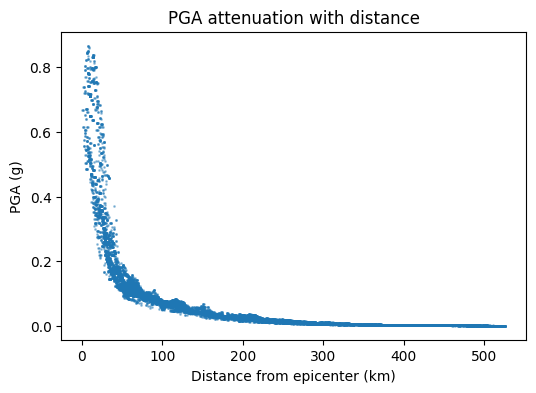

In [11]:
# Approximate Northridge epicenter
epi_lat, epi_lon = 34.213, -118.537

def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # km
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(lat2-lat1)
    dl = np.radians(lon2-lon1)
    a = np.sin(dphi/2)**2 + np.cos(phi1)*np.cos(phi2)*np.sin(dl/2)**2
    return 2*R*np.arcsin(np.sqrt(a))

gdf_affected["dist_km"] = haversine(
    gdf_affected["latitude"], gdf_affected["longitude"],
    epi_lat, epi_lon
)

plt.figure(figsize=(6,4))
plt.scatter(gdf_affected["dist_km"], gdf_affected["pga"], s=1, alpha=0.4)
plt.xlabel("Distance from epicenter (km)")
plt.ylabel("PGA (g)")
plt.title("PGA attenuation with distance")
plt.show()


<Figure size 800x400 with 0 Axes>

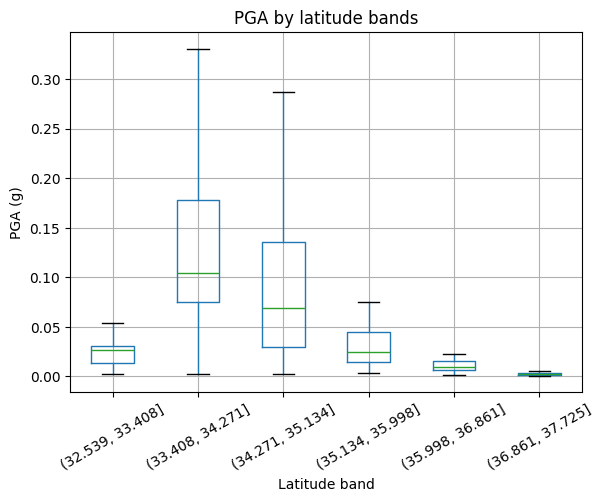

In [12]:
gdf_affected["lat_bin"] = pd.cut(
    gdf_affected["latitude"], bins=6
)

plt.figure(figsize=(8,4))
gdf_affected.boxplot(
    column="pga", by="lat_bin", showfliers=False
)
plt.xticks(rotation=30)
plt.title("PGA by latitude bands")
plt.suptitle("")
plt.xlabel("Latitude band")
plt.ylabel("PGA (g)")
plt.show()


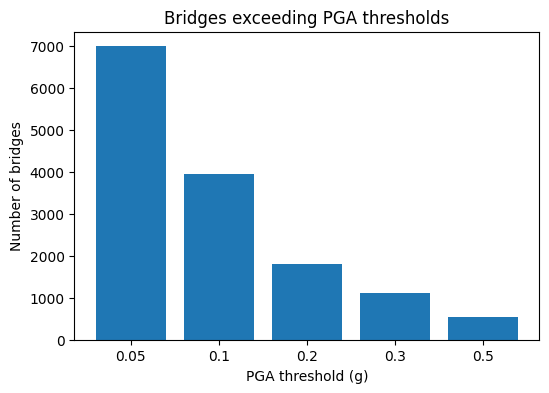

In [13]:
thresholds = [0.05, 0.1, 0.2, 0.3, 0.5]
counts = [(gdf_affected["pga"] > t).sum() for t in thresholds]

plt.figure(figsize=(6,4))
plt.bar([str(t) for t in thresholds], counts)
plt.xlabel("PGA threshold (g)")
plt.ylabel("Number of bridges")
plt.title("Bridges exceeding PGA thresholds")
plt.show()


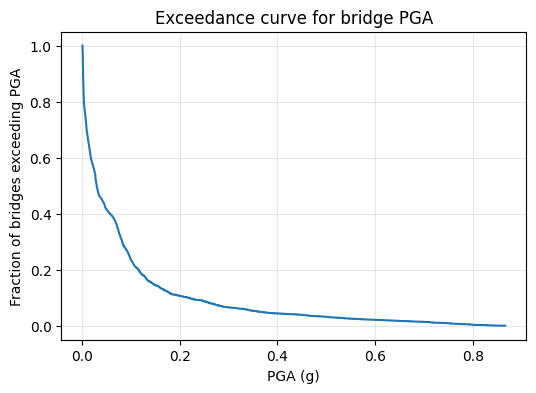

In [14]:
plt.figure(figsize=(6,4))
plt.plot(vals, 1 - cdf)
plt.xlabel("PGA (g)")
plt.ylabel("Fraction of bridges exceeding PGA")
plt.title("Exceedance curve for bridge PGA")
plt.grid(True, alpha=0.3)
plt.show()


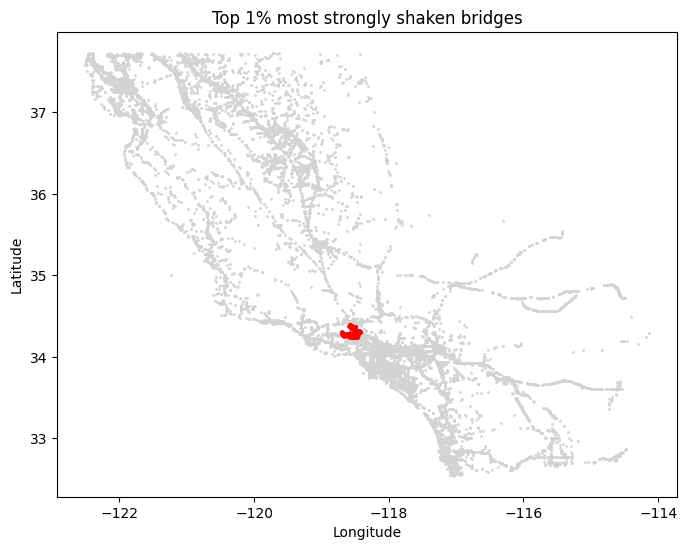

In [15]:
p99 = gdf_affected["pga"].quantile(0.99)
top = gdf_affected[gdf_affected["pga"] >= p99]

ax = gdf_affected.plot(color="lightgrey", markersize=1, figsize=(8,8))
top.plot(ax=ax, color="red", markersize=6)
ax.set_title("Top 1% most strongly shaken bridges")
ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
plt.show()
